In [1]:
import pandas as pd

# Load the first CSV file
df_otherDatabases = pd.read_csv('/home/argis/Desktop/austin/reslit/site/paper/other_databases/comparison/mutations/Full_list_mutations_otherDatabases_clean.csv')
print("Full_list_mutations_otherDatabases.csv:")
print(df_otherDatabases.head())
print(f"\nShape: {df_otherDatabases.shape}")
print(f"\nColumns: {df_otherDatabases.columns.tolist()}")

Full_list_mutations_otherDatabases.csv:
    Database Nucleotide_Change Protein_Change  Gene Encodes  \
0  ResFinder               NaN           A70T  gyrA     NaN   
1  ResFinder               NaN           D85Y  gyrA     NaN   
2  ResFinder               NaN           T86I  gyrA     NaN   
3  ResFinder               NaN           T86I  gyrA     NaN   
4  ResFinder               NaN           T86I  gyrA     NaN   

             Mechanism                    Resistance              Organism  \
0  Target modification  nalidixic acid|ciprofloxacin  Campylobacter jejuni   
1  Target modification  nalidixic acid|ciprofloxacin  Campylobacter jejuni   
2  Target modification  nalidixic acid|ciprofloxacin  Campylobacter jejuni   
3  Target modification  nalidixic acid|ciprofloxacin  Campylobacter jejuni   
4  Target modification  nalidixic acid|ciprofloxacin  Campylobacter jejuni   

   Validated_by                                              Notes  \
0           NaN                           

In [2]:
# Load the second CSV file
df_Reslit = pd.read_csv('/home/argis/Desktop/austin/reslit/site/paper/other_databases/comparison/mutations/Full_list_mutations_Reslit_antib_bact.csv')
print("Full_list_mutations_Reslit.csv:")
print(df_Reslit.head())
print(f"\nShape: {df_Reslit.shape}")
print(f"\nColumns: {df_Reslit.columns.tolist()}")

Full_list_mutations_Reslit.csv:
  Database Nucleotide_Change Protein_Change  Gene  \
0   Reslit               NaN           A90V  gyrA   
1   Reslit               NaN           A90V  gyrA   
2   Reslit               NaN           S83I  gyrA   
3   Reslit               NaN           S85F  parC   
4   Reslit               NaN           S84L  gyrA   

                         Encodes Mechanism        Resistance  \
0           DNA gyrase subunit A       NaN  fluoroquinolones   
1           DNA gyrase subunit A       NaN  fluoroquinolones   
2           DNA gyrase A subunit       NaN     ciprofloxacin   
3  topoisomerase IV ParC subunit       NaN     ciprofloxacin   
4           DNA gyrase A subunit       NaN     ciprofloxacin   

                     Organism                Validated_by  \
0  Mycobacterium tuberculosis     experimental validation   
1         Mycobacterium bovis     experimental validation   
2     Vibrio parahaemolyticus          PCR and sequencing   
3     Vibrio parahae

In [3]:
import pandas as pd
from pathlib import Path
from itertools import permutations

# ── load files ────────────────────────────────────────────────────────────────
other_path  = Path("/home/argis/Desktop/austin/reslit/site/paper/other_databases/comparison/mutations/Full_list_mutations_otherDatabases_clean.csv")
reslit_path = Path("/home/argis/Desktop/austin/reslit/site/paper/other_databases/comparison/mutations/Full_list_mutations_Reslit_antib_bact.csv")

other  = pd.read_csv(other_path,  dtype=str).fillna("")
reslit = pd.read_csv(reslit_path, dtype=str).fillna("")

# ── normalise keys ────────────────────────────────────────────────────────────
def genus(org: pd.Series) -> pd.Series:
    """First word of organism name (genus level) — kept for reference/inspection only,
    no longer used to restrict matching."""
    return org.str.strip().str.split().str[0].str.lower()

def norm_species(org: pd.Series) -> pd.Series:
    """Full organism name, normalised."""
    return org.str.strip().str.lower()

def norm_nuc(s: pd.Series) -> pd.Series:
    return s.str.strip().str.lower()

def norm_gene(s: pd.Series) -> pd.Series:
    return s.str.strip().str.lower()

other  = other[other["Nucleotide_Change"].str.strip() != ""].copy()
reslit = reslit[reslit["Nucleotide_Change"].str.strip() != ""].copy()

other["_nuc"]     = norm_nuc(other["Nucleotide_Change"])
other["_gene"]     = norm_gene(other["Gene"])
other["_genus"]   = genus(other["Organism"])
other["_species"] = norm_species(other["Organism"])

reslit["_nuc"]     = norm_nuc(reslit["Nucleotide_Change"])
reslit["_gene"]     = norm_gene(reslit["Gene"])
reslit["_genus"]   = genus(reslit["Organism"])
reslit["_species"] = norm_species(reslit["Organism"])

# ── one dataframe per "database", ResLit included ─────────────────────────────
all_dbs = {name: grp.copy() for name, grp in other.groupby("Database")}
all_dbs["ResLit"] = reslit.copy()

def compare(df_a: pd.DataFrame, df_b: pd.DataFrame) -> dict:
    """
    Compare unique mutation(nuc+gene)+organism triples in df_a against df_b.
    Matching is mutation(nuc+gene)-first, organism-second. Reports of the same
    mutation across multiple papers collapse to a single unique entry (sets).
      - Different_from_B        : the nuc+gene combo doesn't appear in B at all
      - Correct_same_species    : the nuc+gene combo appears in B AND at least
                                   one identical organism string is shared
      - Genus_only_diff_species : the nuc+gene combo appears in B BUT the organism
                                   is different (same genus/different species, OR a
                                   completely different genus) — broadened to catch
                                   any organism mismatch, not just within-genus ones
    """
    a_keys = set(zip(df_a["_nuc"], df_a["_gene"], df_a["_species"]))  # unique mutation+organism triples in A
    b_nuc_gene = set(zip(df_b["_nuc"], df_b["_gene"]))
    b_species_by_nuc_gene = (
        df_b.groupby(["_nuc", "_gene"])["_species"].apply(set).to_dict()
    )

    correct, organism_mismatch, not_in_b = 0, 0, 0

    for nuc, gene, species in a_keys:
        if (nuc, gene) not in b_nuc_gene:
            not_in_b += 1
        elif species in b_species_by_nuc_gene.get((nuc, gene), set()):
            correct += 1
        else:
            organism_mismatch += 1

    total = len(a_keys)
    return {
        "Unique_mutation_organism_in_A": total,
        "Correct_same_species":          correct,
        "Genus_only_diff_species":       organism_mismatch,
        "Different_from_B":              not_in_b,
        "Correct_%":                     f"{100*correct/total:.1f}%" if total else "0%",
        "B_total_unique":                len(set(zip(df_b["_nuc"], df_b["_gene"], df_b["_species"]))),
    }

# ── full pairwise comparison: every database vs every other database ─────────
summary_rows = []
for name_a, name_b in permutations(all_dbs.keys(), 2):
    row = {"Database_A": name_a, "Database_B": name_b}
    row.update(compare(all_dbs[name_a], all_dbs[name_b]))
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
print("=== Pairwise mutation(nuc+gene)+organism comparison (every database vs every other) ===\n")
print(summary.to_string(index=False))

summary.to_csv("pairwise_mutation_organism_comparison.csv", index=False)
print("\nSaved → pairwise_mutation_organism_comparison.csv")

=== Pairwise mutation(nuc+gene)+organism comparison (every database vs every other) ===

Database_A Database_B  Unique_mutation_organism_in_A  Correct_same_species  Genus_only_diff_species  Different_from_B Correct_%  B_total_unique
 AMRFinder       CARD                             99                    43                        2                54     43.4%             196
 AMRFinder  ResFinder                             99                    38                        6                55     38.4%             299
 AMRFinder     ResLit                             99                    10                       12                77     10.1%            3268
      CARD  AMRFinder                            196                    43                        8               145     21.9%              99
      CARD  ResFinder                            196                    41                        6               149     20.9%             299
      CARD     ResLit                          

In [4]:
# ── missing mutations per database vs ResLit, saved to separate files ────────
reslit_nuc_gene = set(zip(reslit["_nuc"], reslit["_gene"]))

for name, df in all_dbs.items():
    if name == "ResLit":
        continue

    missing = df[~df.apply(lambda r: (r["_nuc"], r["_gene"]) in reslit_nuc_gene, axis=1)].copy()

    missing_unique = (
        missing
        .groupby(["_nuc", "_gene"])
        .agg(
            Gene=("Gene", "first"),
            Nucleotide_Change=("Nucleotide_Change", "first"),
            Organisms=("Organism", lambda s: "; ".join(sorted(set(s)))),
            Resistance=("Resistance", lambda s: "; ".join(sorted(set(x for x in s if x)))),
            Papers_reporting=("PMID", "nunique"),
            PMIDs=("PMID", lambda s: "; ".join(sorted(set(s)))),
        )
        .reset_index(drop=True)
        .sort_values(["Gene", "Nucleotide_Change"])
    )

    out_file = f"missing_mutations_{name}_vs_ResLit.csv"
    missing_unique.to_csv(out_file, index=False)
    print(f"{name}: {len(missing_unique)} unique mutations (gene+nucleotide change) "
          f"not in ResLit → saved to {out_file}")

AMRFinder: 73 unique mutations (gene+nucleotide change) not in ResLit → saved to missing_mutations_AMRFinder_vs_ResLit.csv
CARD: 143 unique mutations (gene+nucleotide change) not in ResLit → saved to missing_mutations_CARD_vs_ResLit.csv
ResFinder: 246 unique mutations (gene+nucleotide change) not in ResLit → saved to missing_mutations_ResFinder_vs_ResLit.csv


In [5]:
import pandas as pd
from pathlib import Path
from itertools import permutations

# ── load files ────────────────────────────────────────────────────────────────

genes_path  = Path("/home/argis/Desktop/austin/reslit/site/paper/other_databases/comparison/genes/Full_list_genes_Reslit_harmonized_antib_bact.csv")

other        = pd.read_csv(other_path,  dtype=str).fillna("")
reslit       = pd.read_csv(reslit_path, dtype=str).fillna("")
reslit_genes = pd.read_csv(genes_path,  dtype=str).fillna("")

# ── normalise keys ────────────────────────────────────────────────────────────
def genus(org: pd.Series) -> pd.Series:
    """First word of organism name (genus level) — kept for reference/inspection only,
    no longer used to restrict matching."""
    return org.str.strip().str.split().str[0].str.lower()

def norm_species(org: pd.Series) -> pd.Series:
    """Full organism name, normalised."""
    return org.str.strip().str.lower()

def norm_nuc(s: pd.Series) -> pd.Series:
    return s.str.strip().str.lower()

other  = other[other["Nucleotide_Change"].str.strip() != ""].copy()
reslit = reslit[reslit["Nucleotide_Change"].str.strip() != ""].copy()

for df in (other, reslit):
    df["_nuc"]     = norm_nuc(df["Nucleotide_Change"])
    df["_genus"]   = genus(df["Organism"])
    df["_species"] = norm_species(df["Organism"])
    df["_pmid"]    = df["PMID"].str.strip()

reslit_genes["_pmid"] = reslit_genes["PMID"].str.strip()

# ── one dataframe per "database", ResLit included ─────────────────────────────
all_dbs = {name: grp.copy() for name, grp in other.groupby("Database")}
all_dbs["ResLit"] = reslit.copy()

# ── PMIDs shared across ALL 4 databases ────────────────────────────────────────
pmid_sets = {name: set(df["_pmid"].unique()) for name, df in all_dbs.items()}

# Augment ResLit's PMID coverage with papers that only have genes reported
# (no mutations), since those papers still count as ResLit having processed them.
reslit_genes_pmids = set(reslit_genes["_pmid"].unique())
pmid_sets["ResLit"] = pmid_sets["ResLit"] | reslit_genes_pmids

shared_pmids_all = set.intersection(*pmid_sets.values())

print("=== PMIDs per database, and shared across all 4 ===\n")
for name, pmids in pmid_sets.items():
    print(f"  {name}: {len(pmids)} unique PMIDs")
print(f"\n  ResLit PMIDs added from genes file: {len(reslit_genes_pmids - set(reslit['_pmid'].unique()))}")
print(f"\n  Shared across ALL 4 databases: {len(shared_pmids_all)} PMIDs")

# ── export all ResLit PMIDs (mutations + genes, deduplicated) ────────────────
reslit_all_pmids = sorted(pmid_sets["ResLit"])
pd.DataFrame({"PMID": reslit_all_pmids}).to_csv("reslit_all_pmids.csv", index=False)
print(f"\nSaved → reslit_all_pmids.csv  ({len(reslit_all_pmids)} unique PMIDs)")

=== PMIDs per database, and shared across all 4 ===

  AMRFinder: 39 unique PMIDs
  CARD: 70 unique PMIDs
  ResFinder: 57 unique PMIDs
  ResLit: 14961 unique PMIDs

  ResLit PMIDs added from genes file: 13690

  Shared across ALL 4 databases: 0 PMIDs

Saved → reslit_all_pmids.csv  (14961 unique PMIDs)


In [6]:
import pandas as pd
from pathlib import Path

# ── load files ────────────────────────────────────────────────────────────────
genes_path  = Path("/home/argis/Desktop/austin/reslit/site/paper/other_databases/comparison/genes/Full_list_genes_Reslit_harmonized_antib_bact.csv")

other        = pd.read_csv(other_path,  dtype=str).fillna("")
reslit       = pd.read_csv(reslit_path, dtype=str).fillna("")
reslit_genes = pd.read_csv(genes_path,  dtype=str).fillna("")

# ── normalise keys ────────────────────────────────────────────────────────────
def genus(org: pd.Series) -> pd.Series:
    """First word of organism name (genus level) — kept for reference/inspection only,
    no longer used to restrict matching."""
    return org.str.strip().str.split().str[0].str.lower()

def norm_species(org: pd.Series) -> pd.Series:
    """Full organism name, normalised."""
    return org.str.strip().str.lower()

def norm_nuc(s: pd.Series) -> pd.Series:
    return s.str.strip().str.lower()

def norm_gene(s: pd.Series) -> pd.Series:
    return s.str.strip().str.lower()

other  = other[other["Nucleotide_Change"].str.strip() != ""].copy()
reslit = reslit[reslit["Nucleotide_Change"].str.strip() != ""].copy()

for df in (other, reslit):
    df["_nuc"]     = norm_nuc(df["Nucleotide_Change"])
    df["_gene"]    = norm_gene(df["Gene"])
    df["_genus"]   = genus(df["Organism"])
    df["_species"] = norm_species(df["Organism"])
    df["_pmid"]    = df["PMID"].str.strip()

reslit_genes["_pmid"] = reslit_genes["PMID"].str.strip()

# ── one dataframe per external database ───────────────────────────────────────
other_dbs = {name: grp.copy() for name, grp in other.groupby("Database")}

# ResLit PMIDs for the comparison = mutations file PMIDs ∪ genes file PMIDs.
# A paper still counts as "ResLit has seen this" even if only genes (no
# mutations) were extracted from it.
reslit_mut_pmids   = set(reslit["_pmid"].unique())
reslit_genes_pmids = set(reslit_genes["_pmid"].unique())
reslit_pmids = reslit_mut_pmids | reslit_genes_pmids

print(f"ResLit PMIDs from mutations file: {len(reslit_mut_pmids)}")
print(f"ResLit PMIDs added from genes file (mutations-file PMIDs excluded): "
      f"{len(reslit_genes_pmids - reslit_mut_pmids)}")
print(f"ResLit total PMIDs used for comparison: {len(reslit_pmids)}\n")

# ── comparison function (mutation(nuc+gene)-first, organism-second) ──────────
def compare(df_a: pd.DataFrame, df_b: pd.DataFrame) -> dict:
    """
    Compare unique mutation(nuc+gene)+organism triples in df_a against df_b.
      - Different_from_B        : the nuc+gene combo doesn't appear in B at all
      - Correct_same_species    : the nuc+gene combo appears in B AND at least
                                   one identical organism string is shared
      - Genus_only_diff_species : the nuc+gene combo appears in B BUT the organism
                                   is different (any mismatch)
    Returns counts plus the actual missing rows (unique, deduplicated).
    """
    a_keys = set(zip(df_a["_nuc"], df_a["_gene"], df_a["_species"]))
    b_nuc_gene = set(zip(df_b["_nuc"], df_b["_gene"]))
    b_species_by_nuc_gene = df_b.groupby(["_nuc", "_gene"])["_species"].apply(set).to_dict()

    correct, organism_mismatch, missing_keys = 0, 0, set()

    for nuc, gene, species in a_keys:
        if (nuc, gene) not in b_nuc_gene:
            missing_keys.add((nuc, gene))
        elif species in b_species_by_nuc_gene.get((nuc, gene), set()):
            correct += 1
        else:
            organism_mismatch += 1

    total = len(a_keys)

    missing_df = (
        df_a[df_a.apply(lambda r: (r["_nuc"], r["_gene"]) in missing_keys, axis=1)]
        .groupby(["_nuc", "_gene"])
        .agg(
            Gene=("Gene", "first"),
            Nucleotide_Change=("Nucleotide_Change", "first"),
            Organisms=("Organism", lambda s: "; ".join(sorted(set(s)))),
            Resistance=("Resistance", lambda s: "; ".join(sorted(set(x for x in s if x)))),
            Papers_reporting=("PMID", "nunique"),
            PMIDs=("PMID", lambda s: "; ".join(sorted(set(s)))),
        )
        .reset_index(drop=True)
        .sort_values(["Gene", "Nucleotide_Change"])
    )

    return {
        "counts": {
            "Unique_mutation_organism_in_A": total,
            "Correct_same_species":          correct,
            "Genus_only_diff_species":       organism_mismatch,
            "Different_from_B":              len(missing_keys),
            "Correct_%":                     f"{100*correct/total:.1f}%" if total else "0%",
            "B_total_unique":                len(set(zip(df_b["_nuc"], df_b["_gene"], df_b["_species"]))),
        },
        "missing": missing_df,
    }

# ── per-database vs ResLit, restricted to PMIDs shared by that pair ──────────
summary_rows = []

print("=== Shared PMIDs: each database vs ResLit ===\n")
for name, df in other_dbs.items():
    db_pmids = set(df["_pmid"].unique())
    shared_pmids = db_pmids & reslit_pmids
    print(f"  {name}: {len(db_pmids)} PMIDs, {len(reslit_pmids)} ResLit PMIDs, "
          f"{len(shared_pmids)} shared")

    db_shared     = df[df["_pmid"].isin(shared_pmids)].copy()
    reslit_shared = reslit[reslit["_pmid"].isin(shared_pmids)].copy()

    result_db_to_reslit = compare(db_shared, reslit_shared)
    row_db_to_reslit = {"Database_A": name, "Database_B": "ResLit"}
    row_db_to_reslit.update(result_db_to_reslit["counts"])
    summary_rows.append(row_db_to_reslit)

    result_reslit_to_db = compare(reslit_shared, db_shared)
    row_reslit_to_db = {"Database_A": "ResLit", "Database_B": name}
    row_reslit_to_db.update(result_reslit_to_db["counts"])
    summary_rows.append(row_reslit_to_db)

    # ── print + save missing mutations: in this DB (shared papers) but not in ResLit ──
    missing = result_db_to_reslit["missing"]
    print(f"\n--- Mutations in {name} (shared papers) NOT in ResLit "
          f"({len(missing)} unique gene+mutation combos) ---")
    display(missing)

    out_file = f"missing_mutations_{name}_vs_ResLit_shared_pmids.csv"
    missing.to_csv(out_file, index=False)
    print(f"Saved → {out_file}")

summary = pd.DataFrame(summary_rows)
print("\n=== Each database vs ResLit, restricted to shared-PMID papers ===\n")
print(summary.to_string(index=False))

summary.to_csv("db_vs_reslit_comparison_shared_pmids.csv", index=False)
print("\nSaved → db_vs_reslit_comparison_shared_pmids.csv")

ResLit PMIDs from mutations file: 1271
ResLit PMIDs added from genes file (mutations-file PMIDs excluded): 13690
ResLit total PMIDs used for comparison: 14961

=== Shared PMIDs: each database vs ResLit ===

  AMRFinder: 39 PMIDs, 14961 ResLit PMIDs, 7 shared

--- Mutations in AMRFinder (shared papers) NOT in ResLit (8 unique gene+mutation combos) ---


,Gene,Nucleotide_Change,Organisms,Resistance,Papers_reporting,PMIDs
0,BlaOXA-143,A-14G,Acinetobacter pittii,carbapenems,1,32582088
7,BlaOXA-143,G-42A,Acinetobacter pittii,carbapenems,1,32582088
6,blaSHV,C-112A,Klebsiella pneumoniae,cefiderocol|cephalosporins,1,10639363
1,mtrR,A-53del,Neisseria gonorrhoeae,azithromycin|beta lactams|tetracycline,2,12270819; 30087172
2,mtrR,A-56C,Neisseria gonorrhoeae,beta lactams|tetracycline,1,30087172
3,norM,A-7G,Neisseria gonorrhoeae,quinolones,1,12533487
5,norM,C-104T,Neisseria gonorrhoeae,quinolones,1,12533487
4,rrl,A2118G,Streptococcus pneumoniae,macrolides|streptogramins,1,11120988


Saved → missing_mutations_AMRFinder_vs_ResLit_shared_pmids.csv
  CARD: 70 PMIDs, 14961 ResLit PMIDs, 10 shared

--- Mutations in CARD (shared papers) NOT in ResLit (27 unique gene+mutation combos) ---


,Gene,Nucleotide_Change,Organisms,Resistance,Papers_reporting,PMIDs
1,rrl,a1410g,Helicobacter pylori,clarithromycin,1,32708761
2,rrl,a2045g,Neisseria gonorrhoeae,azithromycin,1,30917979
3,rrl,a2129c,Streptococcus pneumoniae,multiple antibiotics,1,11120988
4,rrl,a2143g,Helicobacter pylori,clarithromycin,1,32708761
5,rrl,a2167g,Helicobacter pylori,clarithromycin,1,32708761
6,rrl,a2451t,Thermus thermophilus,pleuromutilins,1,32526926
11,rrl,c1707t,Helicobacter pylori,clarithromycin,1,32708761
12,rrl,c2248t,Helicobacter pylori,clarithromycin,1,32708761
13,rrl,c2452t,Thermus thermophilus,pleuromutilins,1,32526926
14,rrl,c2922t,Helicobacter pylori,clarithromycin,1,32708761


Saved → missing_mutations_CARD_vs_ResLit_shared_pmids.csv
  ResFinder: 57 PMIDs, 14961 ResLit PMIDs, 9 shared

--- Mutations in ResFinder (shared papers) NOT in ResLit (125 unique gene+mutation combos) ---


,Gene,Nucleotide_Change,Organisms,Resistance,Papers_reporting,PMIDs
89,Rv0678,ins193G,Mycobacterium tuberculosis,bedaquiline|clofazimine,1,25010492
107,Rv0678,ins39A,Mycobacterium tuberculosis,bedaquiline|clofazimine,1,25010492
0,eis,A-13G,Mycobacterium tuberculosis,kanamycin,1,23705640
122,fabG1,T-8A,Mycobacterium tuberculosis,isoniazid,1,22461677
123,fabG1,T-8C,Mycobacterium tuberculosis,isoniazid,1,22461677
...,...,...,...,...,...,...
7,rrl,C2603T,Neisseria gonorrhoeae,macrolides,1,12183262
8,rrl,C2604T,Neisseria gonorrhoeae,macrolides,1,12183262
9,rrl,C2610T,Neisseria gonorrhoeae,macrolides,1,12183262
5,rrs,C1192T,Neisseria gonorrhoeae,spectinomycin,1,24982323


Saved → missing_mutations_ResFinder_vs_ResLit_shared_pmids.csv

=== Each database vs ResLit, restricted to shared-PMID papers ===

Database_A Database_B  Unique_mutation_organism_in_A  Correct_same_species  Genus_only_diff_species  Different_from_B Correct_%  B_total_unique
 AMRFinder     ResLit                              9                     1                        0                 8     11.1%               7
    ResLit  AMRFinder                              7                     1                        0                 4     14.3%               9
      CARD     ResLit                             31                     4                        0                27     12.9%              19
    ResLit       CARD                             19                     4                        0                15     21.1%              31
 ResFinder     ResLit                            137                     6                        6               125      4.4%              39
    R

## Mutation Overlap: Venn Diagrams & Validation Tiers

Mutation identity here matches how the live site actually groups mutations
(`lib/actions/browse.ts` → `mutationGroupKey`): **Gene + Protein_Change**, falling
back to **Gene + Nucleotide_Change** when there's no protein change, falling back to
a per-row id when neither is present. Unlike the comparisons above, this does **not**
require `Nucleotide_Change` to be filled in — protein-only rows (the majority of the
external-database rows) are included, same as the site's importer
(`scripts/import-mutations-csv.mjs`).

The match is **case-sensitive**, same as the site's code — `mutationGroupKey()` only
trims whitespace, it never lowercases. An earlier version of this notebook lowercased
everything, which silently merged mutations the site treats as distinct (e.g. `A90V`
vs `a90v`, or a gene name with inconsistent capitalisation across databases). That
under-counted the total and inflated Confirmed; switching to case-sensitive matching
reproduces the site's live Total/Confirmed/Established numbers exactly.

**Organism is intentionally not part of the identity.** Checked the site's tier logic
directly (`_fetchMutationValidationTiers` in `lib/actions/browse.ts`): a mutation's
`organisms_observed_in` is stored per-row as descriptive metadata only — it never
enters the grouping key or the tier decision. So the same Gene+change reported in five
different organisms is still one mutation here, matching production behaviour exactly.

**Validation tiers** (same rules the site uses, minus curator status which isn't in
these export CSVs):
- **Confirmed** — appears in ≥ 2 source databases
- **Established** — only in external databases (AMRFinder / CARD / ResFinder), not in ResLit
- **Supported** — ResLit-only, backed by ≥ 3 distinct PMIDs
- **Candidate** — everything else (ResLit-only, < 3 PMIDs)

**A real quirk in the site's tier logic, replicated exactly below:** a row with *both*
a Protein_Change and a Nucleotide_Change gets pushed into two separate lookup buckets
(`gene::p::protein` and `gene::n::nuc` — two `if`s, not `if/elif`), and that row's own
tier is computed by *merging* the databases/PMIDs from both buckets. Only the displayed
"Total Mutations" grouping uses a single protein-priority key; for that, each group
takes the *best* tier among its member rows. This — not export staleness — is what
produces the Supported/Candidate split, and reproduces the site's numbers exactly
(verified: 13,593 total / 1,738 Confirmed / 2,355 Established / 402 Supported / 9,098
Candidate, all four matching).

**Display note:** "AMRFinder" in the underlying CSVs is the site's "Reference Gene
Catalog" source. Charts below relabel it "Ref Gene Catalogue" for display only — the
underlying `Database` value used for matching/tier logic is untouched.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# ── mutation identity, matching the site's own grouping key ──────────────────
# lib/actions/browse.ts::mutationGroupKey(): Protein_Change takes priority over
# Nucleotide_Change; falls back to a row id if neither is present. No
# Nucleotide_Change-required filter here (unlike the comparisons above), and no
# organism component — matching production exactly.
other_m  = pd.read_csv(other_path,  dtype=str).fillna("")
reslit_m = pd.read_csv(reslit_path, dtype=str).fillna("")

def add_group_key(df: pd.DataFrame) -> pd.DataFrame:
    # Case-sensitive, matching the site's mutationGroupKey() exactly (it only
    # trims, it never lowercases) — lowercasing here previously merged
    # mutations the site treats as distinct (e.g. "A90V" vs "a90v", or a gene
    # name with inconsistent capitalisation across databases), which
    # under-counted the total and over-counted Confirmed.
    gene    = df["Gene"].str.strip()
    protein = df["Protein_Change"].str.strip()
    nuc     = df["Nucleotide_Change"].str.strip()
    fallback = "id::" + df.index.astype(str)
    change = np.where(protein != "", "p::" + protein,
             np.where(nuc != "", "n::" + nuc, fallback))
    df["_key"] = gene + "::" + change
    return df

other_m  = add_group_key(other_m)
reslit_m = add_group_key(reslit_m)

mut_sets = {name: set(grp["_key"]) for name, grp in other_m.groupby("Database")}
mut_sets["ResLit"] = set(reslit_m["_key"])

db_names    = ["ResLit"] + [n for n in mut_sets if n != "ResLit"]
other_names = db_names[1:]

# Display-only renaming for plots: "AMRFinder" in these CSVs is the site's "Reference
# Gene Catalog" source database. Only affects chart titles/legends/axis labels below —
# db_names/other_names/mut_sets keep the raw "AMRFinder" value everywhere else (tier
# computation, exports, printed tables) so matching logic stays correct.
DISPLAY_NAME = {"AMRFinder": "Ref Gene Catalogue"}
def disp(name: str) -> str:
    return DISPLAY_NAME.get(name, name)

print("Unique mutations (Gene + Protein_Change, falling back to Nucleotide_Change) per database:")
for name in db_names:
    print(f"  {name:10s}: {len(mut_sets[name])}")

Unique mutations (Gene + Protein_Change, falling back to Nucleotide_Change) per database:
  ResLit    : 10939
  AMRFinder : 1424
  CARD      : 2283
  ResFinder : 1236


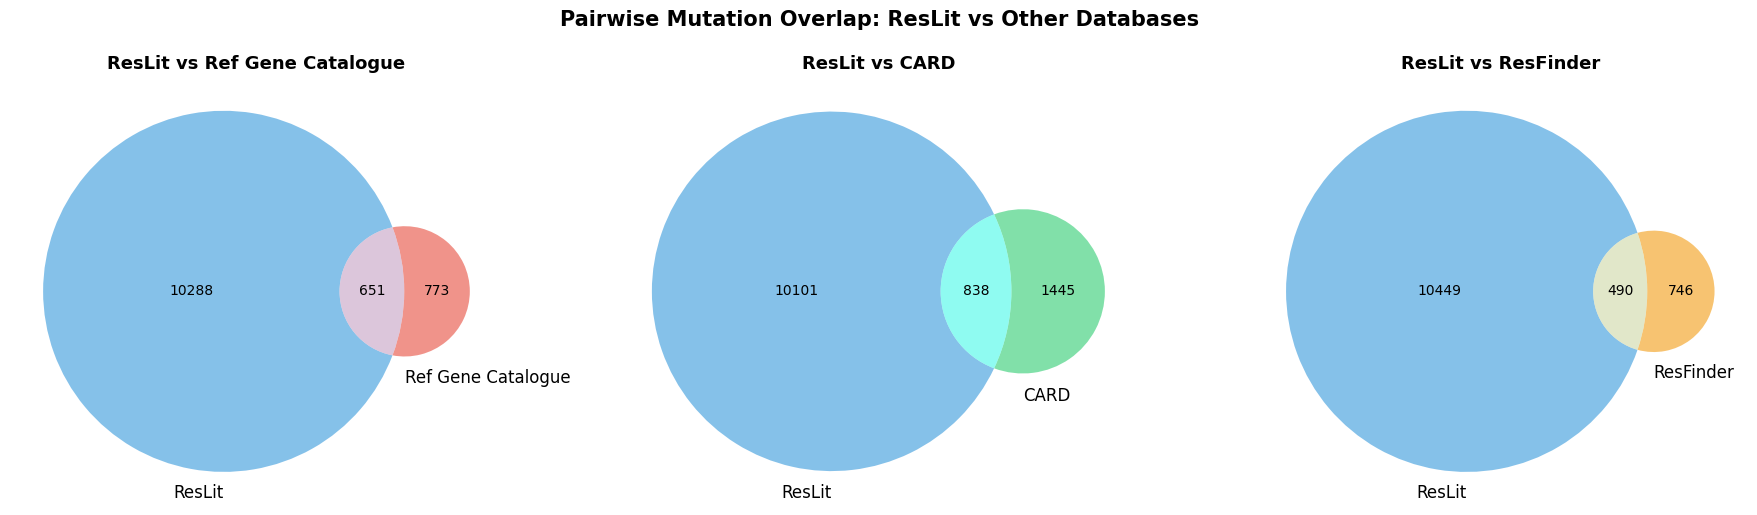

Mutations shared with ResLit, per database:
  AMRFinder :  651 / 1424 shared with ResLit (45.7%)
  CARD      :  838 / 2283 shared with ResLit (36.7%)
  ResFinder :  490 / 1236 shared with ResLit (39.6%)


In [8]:
# ── pairwise Venn diagrams: ResLit vs each other database ───────────────────
reslit_muts = mut_sets["ResLit"]

fig, axes = plt.subplots(1, len(other_names), figsize=(6 * len(other_names), 5))
colors = [('#3498db', '#e74c3c'), ('#3498db', '#2ecc71'), ('#3498db', '#f39c12')]

for ax, name, (c1, c2) in zip(axes, other_names, colors):
    venn2([reslit_muts, mut_sets[name]], set_labels=('ResLit', disp(name)), ax=ax,
          set_colors=(c1, c2), alpha=0.6)
    ax.set_title(f'ResLit vs {disp(name)}', fontsize=13, fontweight='bold')

plt.suptitle('Pairwise Mutation Overlap: ResLit vs Other Databases', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Mutations shared with ResLit, per database:")
for n in other_names:
    shared = len(mut_sets[n] & reslit_muts)
    total = len(mut_sets[n])
    print(f"  {n:10s}: {shared:4d} / {total:4d} shared with ResLit ({100*shared/total:.1f}%)")

## 4-Way Venn Diagram (all databases)

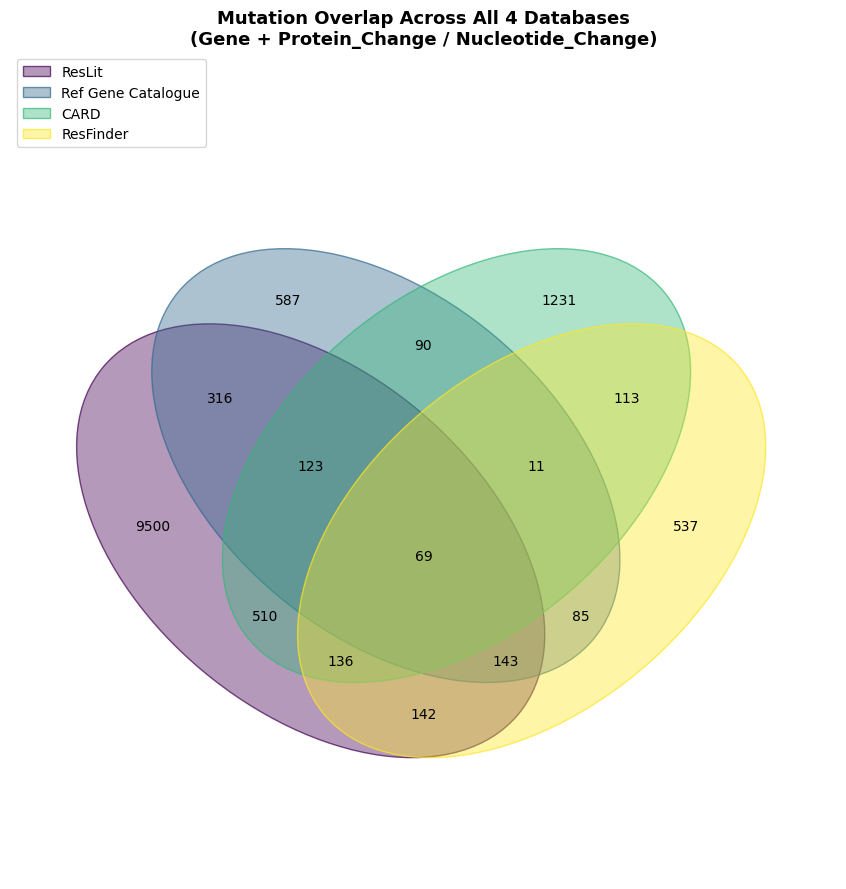

Databases                                           Count
ResLit                                               9500
CARD                                                 1231
AMRFinder                                             587
ResFinder                                             537
ResLit ∩ CARD                                         510
ResLit ∩ AMRFinder                                    316
ResLit ∩ AMRFinder ∩ ResFinder                        143
ResLit ∩ ResFinder                                    142
ResLit ∩ CARD ∩ ResFinder                             136
ResLit ∩ AMRFinder ∩ CARD                             123
CARD ∩ ResFinder                                      113
AMRFinder ∩ CARD                                       90
AMRFinder ∩ ResFinder                                  85
ResLit ∩ AMRFinder ∩ CARD ∩ ResFinder                  69
AMRFinder ∩ CARD ∩ ResFinder                           11


In [9]:
#!pip install venn   # unweighted N-set Venn diagrams (matplotlib_venn only goes up to 3 sets)
from venn import venn as venn_plot
from itertools import product

fig, ax = plt.subplots(figsize=(9, 9))
venn_plot({disp(name): mut_sets[name] for name in db_names}, ax=ax, fontsize=10, legend_loc="upper left")
ax.set_title('Mutation Overlap Across All 4 Databases\n(Gene + Protein_Change / Nucleotide_Change)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# exact counts for every region of the diagram above (unweighted ellipses can be hard to read)
all_muts = set.union(*mut_sets.values())
intersection_counts = {}
for combo in product([False, True], repeat=len(db_names)):
    if not any(combo):
        continue
    label = tuple(db_names[i] for i in range(len(db_names)) if combo[i])
    result = set(all_muts)
    for i, name in enumerate(db_names):
        result &= mut_sets[name] if combo[i] else (all_muts - mut_sets[name])
    if result:
        intersection_counts[label] = len(result)

sorted_intersections = sorted(intersection_counts.items(), key=lambda x: -x[1])
print(f"{'Databases':<50s} {'Count':>6s}")
print("=" * 58)
for label, count in sorted_intersections:
    print(f"{' ∩ '.join(label):<50s} {count:>6d}")

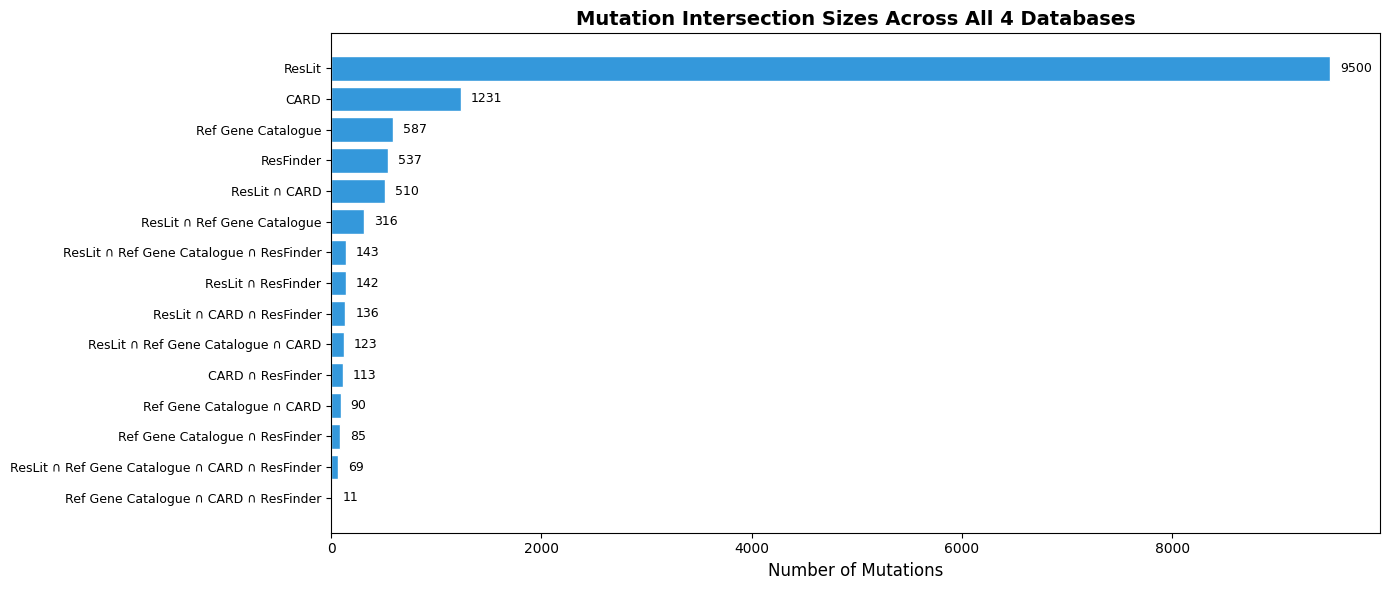

In [10]:
# UpSet-style bar chart (same style as the AMR genes comparison notebook)
labels = [' ∩ '.join(disp(n) for n in l) for l, _ in sorted_intersections]
counts = [c for _, c in sorted_intersections]

fig, ax = plt.subplots(figsize=(14, max(6, len(labels) * 0.4)))
bars = ax.barh(range(len(labels)), counts, color='#3498db', edgecolor='white')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of Mutations', fontsize=12)
ax.set_title('Mutation Intersection Sizes Across All 4 Databases', fontsize=14, fontweight='bold')

for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
            str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Validation Tiers (matching the site's methodology)

In [11]:
# ── tier computation, matching the site's ACTUAL per-row logic exactly ──────
# The site's _fetchMutationValidationTiers (lib/actions/browse.ts) is subtler than
# a single Gene+Change key: a row with BOTH a Protein_Change and a Nucleotide_Change
# gets pushed into TWO buckets (`gene::p::protein` AND `gene::n::nuc` — two separate
# `if`s, not if/elif). Each row's OWN tier is then computed by MERGING the databases
# and ResLit-PMIDs from both buckets. Only the "Total Mutations" grouping (displayed
# count) uses a single protein-priority key — for that, each group takes the BEST
# tier among its member rows. This three-pass structure is what actually explains
# the Supported/Candidate split, not a stale export.

EXTERNAL = set(other_names)  # AMRFinder, CARD, ResFinder

# carry the row's own precomputed `_key` (from add_group_key, same as mut_sets) so the
# final grouping pass lines up exactly with all_muts/mut_sets — no re-derived fallback key
all_rows = [(r["Gene"].strip(), r["Protein_Change"].strip(), r["Nucleotide_Change"].strip(),
             r["Database"].strip(), r["PMID"].strip(), f"o{i}", r["_key"])
            for i, r in other_m.iterrows()] + \
           [(r["Gene"].strip(), r["Protein_Change"].strip(), r["Nucleotide_Change"].strip(),
             "ResLit", r["PMID"].strip(), f"r{i}", r["_key"])
            for i, r in reslit_m.iterrows()]

# Pass 1: push each row's info into BOTH its protein-key and nucleotide-key bucket
by_key: dict[str, dict] = {}
def bucket(key):
    return by_key.setdefault(key, {"databases": set(), "reslit_pmids": set()})

for gene, protein, nuc, database, pmid, rid, _ in all_rows:
    if not gene:
        continue
    keys = []
    if protein: keys.append(f"{gene}::p::{protein}")
    if nuc:     keys.append(f"{gene}::n::{nuc}")
    if not keys: keys.append(f"{gene}::id::{rid}")
    for key in keys:
        b = bucket(key)
        if database:
            b["databases"].add(database)
        if database == "ResLit" and pmid:
            b["reslit_pmids"].add(pmid)

# Pass 2: per-row tier, merging info from BOTH the protein-key and nucleotide-key buckets
row_tier: dict[str, str] = {}
for gene, protein, nuc, database, pmid, rid, _ in all_rows:
    if not gene:
        continue
    p_key = f"{gene}::p::{protein}" if protein else None
    n_key = f"{gene}::n::{nuc}" if nuc else None
    f_key = f"{gene}::id::{rid}" if not (p_key or n_key) else None

    databases, reslit_pmids = set(), set()
    for k in (p_key, n_key, f_key):
        if k and k in by_key:
            databases |= by_key[k]["databases"]
            reslit_pmids |= by_key[k]["reslit_pmids"]

    has_reslit = "ResLit" in databases
    has_external = bool(databases & EXTERNAL)
    cross_db = len(databases) >= 2

    if cross_db:                                      # curator status isn't in these export CSVs
        tier = "Confirmed"
    elif has_external and not has_reslit:
        tier = "Established"
    elif has_reslit and len(reslit_pmids) >= 3:
        tier = "Supported"
    else:
        tier = "Candidate"
    row_tier[rid] = tier

# Pass 3: group by the row's precomputed `_key` (single, protein-priority — identical to
# mut_sets/all_muts), take the best tier among member rows. Matches
# getGroupedMutationTierCounts(), the function behind the displayed stat.
tier_pri = {"Confirmed": 0, "Established": 1, "Supported": 2, "Candidate": 3}
tier_of: dict[str, str] = {}
for gene, protein, nuc, database, pmid, rid, key in all_rows:
    if not gene:
        continue
    t = row_tier[rid]
    if key not in tier_of or tier_pri[t] < tier_pri[tier_of[key]]:
        tier_of[key] = t

tier_counts = {"Confirmed": 0, "Established": 0, "Supported": 0, "Candidate": 0}
for t in tier_of.values():
    tier_counts[t] += 1

total = len(tier_of)

print(f"Total Mutations\n{total:,}\n")
print(" ".join(f"{tier_counts[t]:,} {t}" for t in ["Confirmed", "Established", "Supported", "Candidate"]))

Total Mutations
13,593

1,738 Confirmed 2,355 Established 402 Supported 9,098 Candidate


## Export Results

In [12]:
# Build a dataframe with each mutation, which databases it appears in, and its validation tier
rows = []
for key in sorted(all_muts):
    gene, rest = key.split("::", 1)
    change_type, change_val = rest.split("::", 1)
    rows.append({
        "Gene": gene,
        "Change_Type": {"p": "Protein_Change", "n": "Nucleotide_Change", "id": "id_fallback"}[change_type],
        "Change": change_val,
        **{f"in_{name}": key in mut_sets[name] for name in db_names},
        "num_databases": sum(key in mut_sets[name] for name in db_names),
        "Validation_Tier": tier_of[key],
    })

mutation_membership = pd.DataFrame(rows)
mutation_membership.to_csv("mutation_database_membership.csv", index=False)
print(f"Saved {len(mutation_membership)} mutations to 'mutation_database_membership.csv'")
print("\nBreakdown by number of databases containing each mutation:")
print(mutation_membership["num_databases"].value_counts().sort_index().to_string())
print("\nBreakdown by validation tier:")
print(mutation_membership["Validation_Tier"].value_counts().reindex(["Confirmed", "Established", "Supported", "Candidate"]).to_string())

Saved 13593 mutations to 'mutation_database_membership.csv'

Breakdown by number of databases containing each mutation:
num_databases
1    11855
2     1256
3      413
4       69

Breakdown by validation tier:
Validation_Tier
Confirmed      1738
Established    2355
Supported       402
Candidate      9098
